<a href="https://colab.research.google.com/github/Gcarmnonapy7/FIAP-Aurora-Siger/blob/main/Aurora_siger.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Pipeline de Machine Learning

```
DATA LOADING & CLEANING → EDA → FEATURE ENGINEERING → DATA SPLITTING → TRAINING → VALIDATION ⇄ HYPERPARAMETER TUNING → SAVE ARTEFACT
```

> **Nota:** Validação e Hyperparameter Tuning formam um ciclo iterativo — ajusta-se, valida-se, repete-se até encontrar a melhor configuração.

| Etapa | O que faz |
|-------|-----------|
| **Data Loading & Cleaning** | Carregar os dados brutos e tratar valores ausentes, duplicados ou inconsistentes |
| **EDA** (Exploratory Data Analysis) | Visualizar distribuições, correlações e padrões para entender os dados antes de modelar |
| **Feature Engineering** | Criar, transformar ou selecionar variáveis que melhorem a capacidade preditiva do modelo |
| **Data Splitting** | Dividir em treino, validação e teste para avaliar o modelo em dados que ele nunca viu |
| **Training** | Ajustar os parâmetros do modelo aos dados de treino |
| **Validation** | Medir o desempenho em dados de validação para detectar overfitting ou underfitting |
| **Hyperparameter Tuning** | Otimizar configurações externas ao modelo (ex: número de árvores, kernel) que não são aprendidas no treino |
| **Save Artefact** | Serializar o modelo treinado (ex: `joblib`, `pickle`) para uso em produção |

In [ ]:
# === import libraries ===

import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest

In [ ]:
np.random.seed(42)
n_samples = 1_000_000
anomalies_ratio = 0.03
n_anomalies = int(n_samples * anomalies_ratio)

In [ ]:
tank_pressure_data = np.random.normal(loc=305, scale=15, size=n_samples - n_anomalies)
failure_prob = 1 / (1 + np.exp(-(tank_pressure_data - 320) / 10)) # if too high change the number of the division
failure_prob = np.clip(failure_prob, 0, 1) # Ensure probabilities are between 0 and 1

df_non_anomaly = pd.DataFrame({
    'temperatura_interna': np.random.normal(loc=22, scale=1.5, size=n_samples - n_anomalies),       # ISS: 18–26°C, média 21–23°C
    'temperatura_externa': np.random.normal(loc=10, scale=8, size=n_samples - n_anomalies),         # LEO: -65°C a +125°C
    'integridade_estrutural': np.random.binomial(1, failure_prob),  # bernoulli distribution for when the pressure is to high (above 320)
    'energy': np.random.beta(8, 2, n_samples - n_anomalies) * 100,                      # carga da bateria (%)
    'vibration': np.random.normal(loc=0.3, scale=0.1, size=n_samples - n_anomalies),                 # pré-decolagem: ~0.1–0.5g
    'tank_pressure': tank_pressure_data,   # LOX/LH2 pump-fed (atm)
    'navegation' : np.random.binomial(1, 1 - failure_prob, size=n_samples - n_anomalies),
})

# Generate data specifically for anomalies
# tank_pressure_data_anomaly = np.random.normal(loc=305, scale=15, size=n_anomalies)
# failure_prob_anomaly = 1 / (1 + np.exp(-(tank_pressure_data_anomaly - 320) / 10))
# failure_prob_anomaly = np.clip(failure_prob_anomaly, 0, 1)

# df_anomaly = pd.DataFrame({
#     'temperatura_interna': np.random.normal(loc=22, scale=1.5, size= n_anomalies),       # ISS: 18–26°C, média 21–23°C
#     'temperatura_externa': np.random.normal(loc=10, scale=8, size= n_anomalies),         # LEO: -65°C a +125°C
#     'integridade_estrutural': np.random.binomial(1, failure_prob_anomaly),  # Use anomaly-specific failure_prob
#     'energy': np.random.beta(8, 2,  n_anomalies) * 100,                      # carga da bateria (%)
#     'vibration': np.random.normal(loc=0.3, scale=0.1, size= n_anomalies),                 # pré-decolagem: ~0.1–0.5g
#     'tank_pressure': tank_pressure_data_anomaly,   # Use anomaly-specific tank_pressure_data
#     'navegation' : np.random.binomial(1, 1 - failure_prob_anomaly, size= n_anomalies),
# })

In [ ]:
df_non_anomaly.head()

,temperatura_interna,temperatura_externa,integridade_estrutural,energy,vibration,tank_pressure,navegation
0,23.006207,8.750201,1,73.167188,0.271076,306.862678,1
1,21.361117,2.137934,0,67.852592,0.421997,313.363255,0
2,20.557901,12.534480,0,62.086808,0.269517,304.342142,1
3,22.789020,14.676994,0,86.041107,0.332774,321.174358,0
4,20.607709,2.836247,0,60.508544,0.464837,302.819478,1


In [ ]:
print(f'{df_non_anomaly.shape}')

(970000, 7)


In [ ]:
df_non_anomaly.describe()

,temperatura_interna,temperatura_externa,integridade_estrutural,energy,vibration,tank_pressure,navegation
count,970000.000000,970000.000000,970000.000000,970000.000000,970000.000000,970000.000000,970000.000000
mean,22.000100,10.007708,0.253960,80.004159,0.300186,305.004980,0.745616
std,1.501132,8.000658,0.435275,12.043857,0.099913,15.003952,0.435514
min,14.595075,-27.538615,0.000000,14.885498,-0.171779,236.326431,0.000000
25%,20.987281,4.599512,0.000000,72.789916,0.232698,294.862904,0.000000
50%,22.000283,10.009976,0.000000,82.041724,0.300102,305.009249,1.000000
75%,23.013940,15.417614,1.000000,89.269196,0.367468,315.110917,1.000000
max,29.139530,51.282038,1.000000,99.982050,0.767396,377.055641,1.000000


## EDA (Exploratory data analysis)

<Figure size 640x480 with 0 Axes>

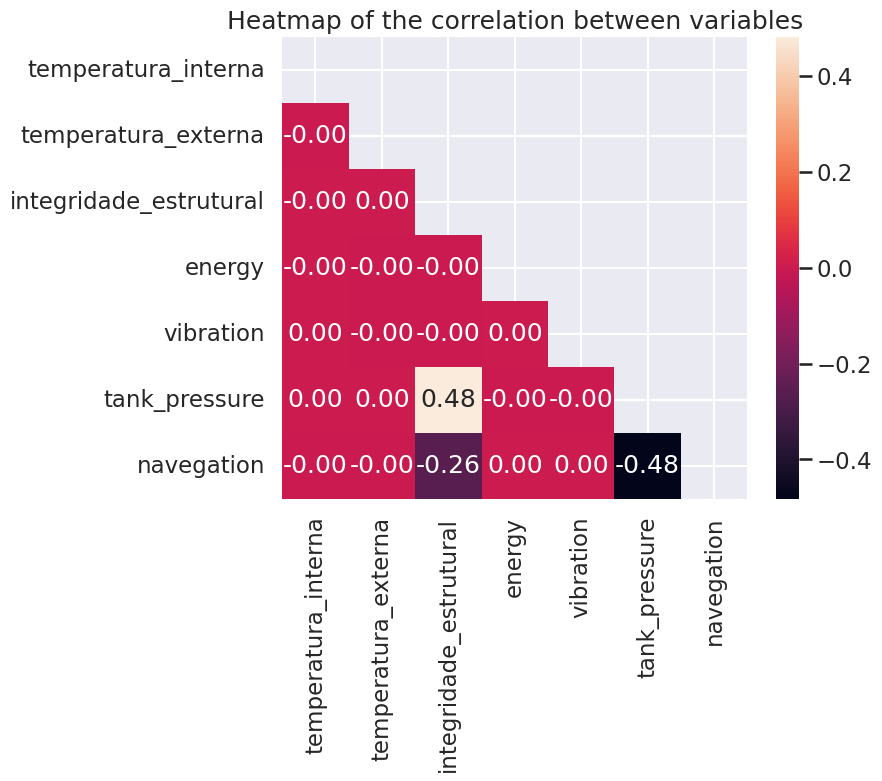

In [ ]:
from numpy._core.defchararray import index
import seaborn
import matplotlib.pyplot as plt

# === Plot configurations ===
sns.set_style('darkgrid')
sns.set_context('talk') # bold text for readable
sns.despine() # remove the top and right spines

def heatmap_plot(data:pd.DataFrame) -> None:
    plt.figure(figsize=(7.5,6))
    plt.title('Heatmap of the correlation between variables')
    corr = data.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool)) # upper triangular (down visualization) for easier visualization
    sns.heatmap(corr,mask=mask,annot=True,fmt=".2f")
    plt.show()

def distribution_plot(data:pd.DataFrame) -> None:

    n_vars = len(data.columns)
    n_cols = 2
    n_rows = (n_vars + n_cols -1 ) // n_cols # make sure that has enough rows for the plots

    for idx, col in enumerate(data.columns,start=1):
      plt.figure(figsize=(8,6))
      plt.subplot(n_rows,n_cols,idx) # subplot expects to start at one
      plt.title(f"Distribution plot for {col}")
      sns.histplot(data[col],kde=True,bins=20)
      plt.tight_layout()
      plt.show()

def statistical_analysis(data:pd.DataFrame):

    valid_columns = list(data.columns)
    for col in data.columns:
      print(f"{col}")
      print("*" * 60)

      print("*" * 60)



heatmap_plot(df_non_anomaly) # not so much correlated (only tank and pressure)

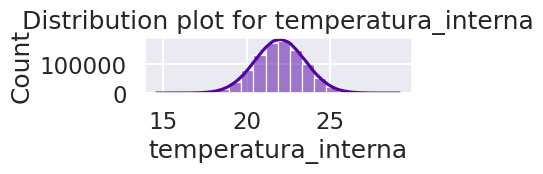

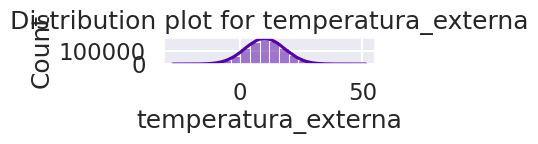

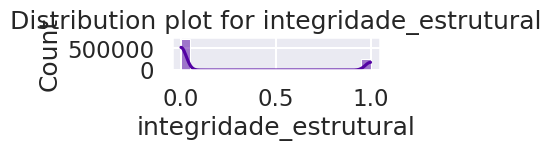

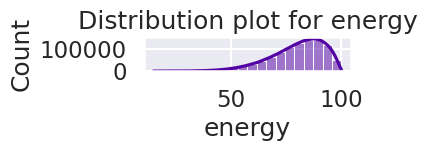

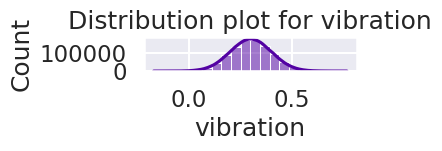

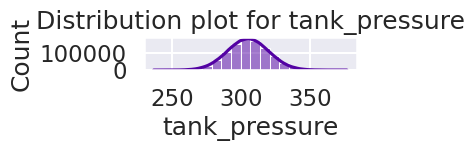

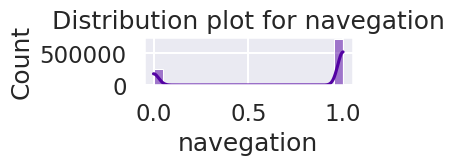

In [ ]:
distribution_plot(data=df_non_anomaly)

##Creating the models from scratch

In [ ]:
# === Decision tree from scratch ===
class DecisionTree:
  def __init__(self):
    pass


In [ ]:
# Isolation tree from strach
class IsolationTree:
  def __init__(self):
    pass

---

# Entregáveis do Projeto Aurora SIGER

Roteiro de desenvolvimento do trabalho em grupo. Cada seção abaixo corresponde a um entregável da atividade.

## 1.1 Organização e descrição da telemetria

Interpretar dados referentes a:
- Temperatura interna e externa
- Integridade estrutural (0/1)
- Níveis de energia (%)
- Pressão dos tanques
- Status dos módulos críticos

## 1.2 Algoritmo de verificação

Construir um algoritmo (fluxograma/pseudocódigo) capaz de decidir:
- **"PRONTO PARA DECOLAR"** ou **"DECOLAGEM ABORTADA"**

Com base em faixas seguras predefinidas para cada variável de telemetria.

## 1.3 Script em Python

Implementar a lógica do algoritmo em Python, simulando:
- Leitura dos dados de telemetria
- Execução das verificações contra faixas seguras
- Resultado final impresso: **"PRONTO PARA DECOLAR"** ou **"DECOLAGEM ABORTADA"**

## 1.4 Análise energética

Calcular autonomia inicial considerando:
- Capacidade total (kWh)
- Carga atual (%)
- Consumo estimado na decolagem
- Perdas energéticas

## 1.5 Análise assistida por IA

Solicitar à IA:
- Classificação dos dados de telemetria
- Identificação de possíveis anomalias
- Sugestões de risco

## 1.6 Reflexão crítica

Texto sobre:
- Ética e responsabilidade no uso de IA e automação em sistemas críticos
- Impacto social da exploração espacial
- Sustentabilidade tecnológica